# 02 — the corpus in appearance space

**Summary.** The headline of the whole embedding effort, with its baseline attached:

* **Appearance neighbours are 66.3% same-museum against a 39.0% chance baseline (1.70x).** Metadata
  neighbours are 93.6% (2.40x). Both beat chance; the picture crosses the museum wall that the
  catalogue does not. **33.7% of appearance neighbours come from another museum — 133,234 pairs**
  no catalogue query could have produced. The effect also decays with rank (77.0% at rank 1, 62.7%
  at rank 20), which a photography-convention artefact would not do.
* **A cosine on its own says nothing.** Neighbour cosines (median 0.872) look impressive until they
  are read against the corpus band, where two *random* works sit at 0.643 and the maximum over
  1.1M pairs is 0.969. Everything here is reported against that band.
* **The space is hubbed, but mildly.** The top 1% of works absorb 4.7% of all neighbour slots
  against 1% if flat, one work is in 176 lists, and 1.9% of works are in nobody's. So "X and Y are
  both near Z" is sometimes a fact about Z — worth knowing, not disqualifying.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import kusama as k

m = k.load_manifest()
X, order = k.load_clip()
knn = k.load_knn()
b = k.band()

## Same-museum, by rank

If the encoder were reading museum photography conventions rather than pictures, the effect would be
flat across ranks and near 100%. If it were reading nothing, it would sit on the chance line.

same-museum over all k=20 neighbours: 0.6634 vs 0.3897 — 1.70x chance
same-museum at rank 1: 0.7698 vs 0.3897 — 1.98x chance
same-museum at rank 20: 0.6268 vs 0.3897 — 1.61x chance

cross-museum neighbour pairs: 33.7% of 395,820 = 133,234 pairs the catalogue could not have proposed


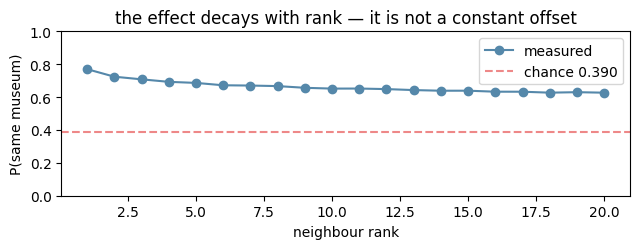

In [2]:
by_rank = knn.groupby("rank").same_museum.mean()
ch = k.museum_chance()
print(k.Reading("same-museum over all k=20 neighbours", knn.same_museum.mean(), ch))
print(k.Reading("same-museum at rank 1", by_rank.loc[1], ch))
print(k.Reading("same-museum at rank 20", by_rank.loc[20], ch))
print(f"\ncross-museum neighbour pairs: {(1 - knn.same_museum.mean())*100:.1f}% of {len(knn):,} = "
      f"{(1 - knn.same_museum).sum():,.0f} pairs the catalogue could not have proposed")
fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.plot(by_rank.index, by_rank.values, marker="o", color="#58a", label="measured")
ax.axhline(ch, color="#e88", ls="--", label=f"chance {ch:.3f}")
ax.set_ylim(0, 1); ax.set_xlabel("neighbour rank"); ax.set_ylabel("P(same museum)")
ax.legend(); ax.set_title("the effect decays with rank — it is not a constant offset")
fig.tight_layout(); plt.show()

## Neighbour cosines against the band

The left distribution is "the nearest 20 works". The right marks are what the band says a *random*
pair looks like. The gap between them is the entire information content of the embedding.

neighbour cosines: min 0.4786  median 0.8719  max 1.0000
corpus band      : min 0.1555  median 0.6428  max 0.9685

0.10% of k=20 'neighbours' are BELOW the median random pair.
Those are works in sparse regions whose 20th neighbour is not near them at all — a kNN always
returns k rows whether or not there are k neighbours.


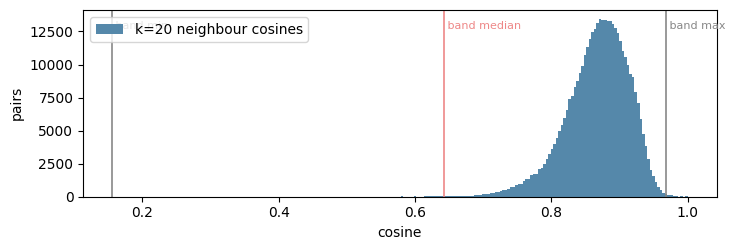

In [3]:
c = knn.cosine
print(f"neighbour cosines: min {c.min():.4f}  median {c.median():.4f}  max {c.max():.4f}")
print(f"corpus band      : min {b['min']:.4f}  median {b['median']:.4f}  max {b['max']:.4f}")
print(f"\n{(c < b['median']).mean():.2%} of k=20 'neighbours' are BELOW the median random pair.")
print("Those are works in sparse regions whose 20th neighbour is not near them at all — a kNN always")
print("returns k rows whether or not there are k neighbours.")
fig, ax = plt.subplots(figsize=(7.5, 2.6))
ax.hist(c, bins=140, color="#58a", label="k=20 neighbour cosines")
for name, v, col in [("band min", b["min"], "#888"), ("band median", b["median"], "#e88"),
                     ("band max", b["max"], "#888")]:
    ax.axvline(v, color=col, lw=1.2); ax.text(v, ax.get_ylim()[1]*0.9, f" {name}", fontsize=8, color=col)
ax.set_xlabel("cosine"); ax.set_ylabel("pairs"); ax.legend(loc="upper left")
fig.tight_layout(); plt.show()

## Hubness

In high-dimensional spaces some points are everyone's neighbour. If a work appears in far more
neighbour lists than 20, then "these two works are both near it" is weak evidence about the two.
The baseline is exact: with 19,791 works each taking 20 neighbours, the mean in-degree is exactly 20.

In [4]:
indeg = knn.neighbour_sha256.value_counts()
indeg = indeg.reindex(order).fillna(0).astype(int)
print(f"in-degree: mean {indeg.mean():.1f} (exactly k by construction), median {indeg.median():.0f}, "
      f"max {indeg.max():,}")
print(f"{(indeg == 0).mean():.1%} of works are in NOBODY's top-20 — they are antihubs")
top_share = indeg.sort_values(ascending=False).head(int(0.01*len(indeg))).sum() / indeg.sum()
print(f"the top 1% of works absorb {top_share:.1%} of all neighbour slots (1% if flat) — "
      f"{top_share*100:.1f}x concentration")
hubs = m.set_index("sha256").loc[indeg.sort_values(ascending=False).head(8).index]
print("\nthe eight biggest hubs:")
for sha, row in hubs.iterrows():
    print(f"  {indeg[sha]:>5}  {row.id:<12} {str(row.classification)[:24]:<24} {str(row.title)[:44]}")

in-degree: mean 20.0 (exactly k by construction), median 15, max 176
1.9% of works are in NOBODY's top-20 — they are antihubs
the top 1% of works absorb 4.7% of all neighbour slots (1% if flat) — 4.7x concentration

the eight biggest hubs:
    176  met-32672    Daggers                  Roundel Dagger
    156  met-547490   Figurine, Baboon         Juvenile Baboon
    155  met-463600   Textiles-Woven-Brocade   Textile with Brocade
    151  cma-94023    Funerary Equipment       Shawabty
    144  met-570754   Mummy, fish              Mummified Fish
    138  aic-87647    textile                  Fragment
    132  aic-269798   prints and drawing       Pietà with Angels (Descent from the Cross)
    130  met-575433   Scoop, winnowing         Winnowing Scoop


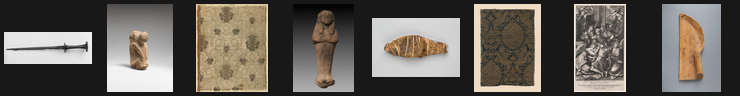

The hubs, as pictures. If they share a look, that look is the space's centre of gravity.


In [5]:
display(k.thumb_grid(list(indeg.sort_values(ascending=False).head(8).index), cols=8, size=88))
print("The hubs, as pictures. If they share a look, that look is the space's centre of gravity.")

## One query, and what it thinks is near it

The point of a picture here is that percentiles are abstract and this is not.

query cma-106865  cma  Hairpin



   1  cos 0.9639  ABOVE the random-pair median  cma  Hairpin
   2  cos 0.9383  ABOVE the random-pair median  cma  Hairpin
   3  cos 0.9369  ABOVE the random-pair median  cma  Hairpin
   4  cos 0.9126  ABOVE the random-pair median  cma  Stick
   5  cos 0.9113  ABOVE the random-pair median  cma  Hairpin
   6  cos 0.8948  ABOVE the random-pair median  met  Statuette of Osiris
   7  cos 0.8933  ABOVE the random-pair median  met  Dagger
   8  cos 0.8924  ABOVE the random-pair median  cma  Chair Leg
   9  cos 0.8907  ABOVE the random-pair median  aic  Figural Staff
  10  cos 0.8893  ABOVE the random-pair median  aic  Wooden Spindle
  11  cos 0.8888  ABOVE the random-pair median  cma  Hairpin


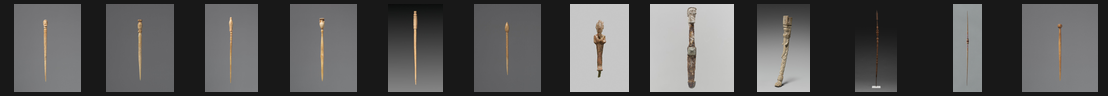

first cell is the query; the rest are ranks 1..11 in order


In [6]:
q = order[7000]
row = m.set_index("sha256").loc[q]
nb = knn[knn.sha256 == q].sort_values("rank")
print(f"query {row.id}  {row.museum}  {str(row.title)[:60]}\n")
for _, r in nb.head(11).iterrows():
    t = m.set_index("id").loc[r.neighbour_id]
    pct = (b["median"] < r.cosine)
    print(f"  {r['rank']:>2}  cos {r.cosine:.4f}  {'ABOVE' if pct else 'below'} the random-pair median  "
          f"{r.neighbour_museum}  {str(t.title)[:44]}")
display(k.thumb_grid([q] + list(nb.head(11).neighbour_sha256), cols=12, size=88))
print("first cell is the query; the rest are ranks 1..11 in order")

## What this does NOT show

The 66.3% is a similarity between *photographs*. Museums light, crop and back their objects
differently, and some of the 1.70x is certainly that convention rather than the works. The honest
version of this claim is: **appearance neighbours cross the museum wall far more often than metadata
neighbours do (34% vs 6.4%), and nothing here separates "the works look alike" from "the studios
look alike".** Notebook 06 is where that question is actually pressed, and it comes back a null.

## Scratch

In [7]:
# yours